In [106]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
TARGET_COL = 'Depression'
ID_COL = 'id'

train_path = '../data/train.csv'
test_path = '../data/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [107]:
# 1. Tách feature và target
drop_cols = [ID_COL, 'Name']

X = train.drop(columns=[TARGET_COL] + drop_cols)
y = train[TARGET_COL]
X_test = test.drop(columns=drop_cols)
test_ids = test[ID_COL]

In [108]:
#2. Chuẩn hoá categorical, xử lý missing theo vai trò và thêm missing indicator
ROLE_COL = 'Working Professional or Student'
STUDENT_ONLY_NUMERIC_COLS = ['Academic Pressure', 'CGPA', 'Study Satisfaction']
WORK_ONLY_NUMERIC_COLS = ['Work Pressure', 'Job Satisfaction']
WORK_ONLY_CATEGORICAL_COLS = ['Profession']
BINARY_YES_NO_COLS = [
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
]


def clean_string_columns(df):
    df = df.copy()
    obj_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in obj_cols:
        # sklearn SimpleImputer can fail on pandas pd.NA, so keep missing as np.nan.
        df[col] = df[col].astype('object')
        df[col] = df[col].where(df[col].notna(), np.nan)
        df[col] = df[col].str.strip()
        df[col] = df[col].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
    return df


def add_missing_indicators(df, cols):
    df = df.copy()
    for col in cols:
        df[f'{col}_is_missing'] = df[col].isna().astype(int)
    return df


def fill_structural_missing_by_role(df):
    df = df.copy()
    is_student = df[ROLE_COL].eq('Student')
    is_professional = df[ROLE_COL].eq('Working Professional')

    for col in STUDENT_ONLY_NUMERIC_COLS:
        if col in df.columns:
            df.loc[is_professional & df[col].isna(), col] = 0

    for col in WORK_ONLY_NUMERIC_COLS:
        if col in df.columns:
            df.loc[is_student & df[col].isna(), col] = 0

    for col in WORK_ONLY_CATEGORICAL_COLS:
        if col in df.columns:
            df.loc[is_student & df[col].isna(), col] = 'Not Applicable'

    return df


def map_yes_no_columns(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map({'No': 0, 'Yes': 1})
    return df


def add_engineered_features(df):
    df = df.copy()

    pressure_cols = ['Academic Pressure', 'Work Pressure']
    satisfaction_cols = ['Study Satisfaction', 'Job Satisfaction']

    if all(col in df.columns for col in pressure_cols):
        df['Total Pressure'] = df[pressure_cols].sum(axis=1)
        df['Max Pressure'] = df[pressure_cols].max(axis=1)

    if all(col in df.columns for col in satisfaction_cols):
        df['Total Satisfaction'] = df[satisfaction_cols].sum(axis=1)
        df['Min Satisfaction'] = df[satisfaction_cols].replace(0, np.nan).min(axis=1)

    if {'Total Pressure', 'Total Satisfaction'}.issubset(df.columns):
        df['Pressure Satisfaction Gap'] = df['Total Pressure'] - df['Total Satisfaction']

    if {'Total Pressure', 'Work/Study Hours'}.issubset(df.columns):
        hours = df['Work/Study Hours'].replace(0, np.nan)
        df['Pressure Per Work Study Hour'] = df['Total Pressure'] / hours

    if {'Total Pressure', 'Financial Stress'}.issubset(df.columns):
        df['Pressure Financial Stress'] = df['Total Pressure'] * df['Financial Stress']

    suicidal_col = 'Have you ever had suicidal thoughts ?'
    if {'Total Pressure', suicidal_col}.issubset(df.columns):
        df['Suicidal Thoughts Pressure'] = df[suicidal_col] * df['Total Pressure']

    return df


def group_rare_categories(train_df, test_df, min_count=30):
    train_df = train_df.copy()
    test_df = test_df.copy()
    cat_cols = train_df.select_dtypes(include=['object', 'string']).columns.tolist()

    for col in cat_cols:
        counts = train_df[col].value_counts(dropna=True)
        keep_values = set(counts[counts >= min_count].index)

        train_mask = train_df[col].notna() & ~train_df[col].isin(keep_values)
        test_mask = test_df[col].notna() & ~test_df[col].isin(keep_values)
        train_df.loc[train_mask, col] = 'Other'
        test_df.loc[test_mask, col] = 'Other'

    return train_df, test_df


X_clean = clean_string_columns(X)
X_test_clean = clean_string_columns(X_test)

missing_cols = X_clean.columns[X_clean.isna().mean() > 0].tolist()

X_clean = add_missing_indicators(X_clean, missing_cols)
X_test_clean = add_missing_indicators(X_test_clean, missing_cols)

X_clean = fill_structural_missing_by_role(X_clean)
X_test_clean = fill_structural_missing_by_role(X_test_clean)

X_clean = map_yes_no_columns(X_clean, BINARY_YES_NO_COLS)
X_test_clean = map_yes_no_columns(X_test_clean, BINARY_YES_NO_COLS)

X_clean = add_engineered_features(X_clean)
X_test_clean = add_engineered_features(X_test_clean)

X_clean, X_test_clean = group_rare_categories(X_clean, X_test_clean, min_count=30)

# Bỏ feature profession
# X_clean = X_clean.drop(columns=['Profession'])
# X_test_clean = X_test_clean.drop(columns=['Profession'])
# Bỏ thì score giảm

In [109]:
# 3.Chia train/val có stratify 
X_train, X_val, y_train, y_val = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [110]:
# 4.Tạo Preprocessing Pipeline cho tree-based models
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', make_onehot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ],
    remainder='drop',
)

In [111]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test_clean)

In [112]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index,
)
X_val_processed_df = pd.DataFrame(
    X_val_processed,
    columns=feature_names,
    index=X_val.index,
)

In [113]:
# Chạy thử nhiều biến thể CatBoost/XGBoost và so sánh trong một lần chạy
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


missing_optional_packages = []
tree_models = {}

try:
    from xgboost import XGBClassifier

    xgboost_base_params = {
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    }
    tree_models.update(
        {
            'XGBoost 1': XGBClassifier(
                **xgboost_base_params,
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
            ),
            'XGBoost 2': XGBClassifier(
                **xgboost_base_params,
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
            ),
            'XGBoost 3': XGBClassifier(
                **xgboost_base_params,
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.85,
                colsample_bytree=0.85,
            ),
            'XGBoost 4': XGBClassifier(
                **xgboost_base_params,
                n_estimators=400,
                learning_rate=0.04,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.9,
                reg_lambda=2.0,
            ),
            'XGBoost 5': XGBClassifier(
                **xgboost_base_params,
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=3.0,
            ),
        }
    )
except ImportError:
    missing_optional_packages.append('xgboost')

try:
    from catboost import CatBoostClassifier

    catboost_base_params = {
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
    }
    tree_models.update(
        {
            'CatBoost 1': CatBoostClassifier(
                **catboost_base_params,
                iterations=300,
                learning_rate=0.05,
                depth=6,
            ),
            'CatBoost 2': CatBoostClassifier(
                **catboost_base_params,
                iterations=500,
                learning_rate=0.03,
                depth=6,
            ),
            'CatBoost 3': CatBoostClassifier(
                **catboost_base_params,
                iterations=400,
                learning_rate=0.04,
                depth=5,
                l2_leaf_reg=5,
            ),
            'CatBoost 4': CatBoostClassifier(
                **catboost_base_params,
                iterations=500,
                learning_rate=0.03,
                depth=7,
                l2_leaf_reg=5,
            ),
            'CatBoost 5': CatBoostClassifier(
                **catboost_base_params,
                iterations=600,
                learning_rate=0.025,
                depth=6,
                l2_leaf_reg=7,
            ),
        }
    )
except ImportError:
    missing_optional_packages.append('catboost')

if missing_optional_packages:
    print(
        'Skipped optional models because packages are not installed: '
        + ', '.join(missing_optional_packages)
    )
    print('Install them with: pip install -r ml/requirements.txt')

if not tree_models:
    raise ValueError('No CatBoost/XGBoost models are available.')

results = []
reports = {}
fitted_models = {}

for name, classifier in tree_models.items():
    model = Pipeline(
        steps=[
            ('preprocess', clone(preprocessor)),
            ('classifier', classifier),
        ]
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]

    reports[name] = classification_report(y_val, val_pred)
    fitted_models[name] = model
    results.append(
        {
            'model': name,
            'accuracy': accuracy_score(y_val, val_pred),
            'precision': precision_score(y_val, val_pred),
            'recall': recall_score(y_val, val_pred),
            'f1': f1_score(y_val, val_pred),
            'roc_auc': roc_auc_score(y_val, val_proba),
        }
    )

results_df = pd.DataFrame(results).sort_values(
    by=['roc_auc', 'f1'],
    ascending=False,
).reset_index(drop=True)

display(results_df)

best_model_name = results_df.loc[0, 'model']
best_model = fitted_models[best_model_name]

print(f'Best model by ROC-AUC: {best_model_name}')
print(reports[best_model_name])

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost 4,0.938451,0.840621,0.815959,0.828106,0.974395
1,CatBoost 4,0.939410,0.847471,0.812830,0.829789,0.974385
2,CatBoost 1,0.939765,0.849775,0.812048,0.830483,0.974377
3,CatBoost 2,0.939446,0.848640,0.811461,0.829634,0.974369
4,CatBoost 5,0.939410,0.847897,0.812243,0.829687,0.974360
5,XGBoost 5,0.938451,0.840895,0.815568,0.828038,0.974347
6,CatBoost 3,0.939055,0.848156,0.809505,0.828380,0.974336
7,XGBoost 2,0.938842,0.843877,0.814004,0.828671,0.974328
8,XGBoost 1,0.938806,0.843010,0.814981,0.828759,0.974302
9,XGBoost 3,0.938060,0.841646,0.811852,0.826481,0.974177


Best model by ROC-AUC: XGBoost 4
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     23027
           1       0.84      0.82      0.83      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.89      0.90     28140
weighted avg       0.94      0.94      0.94     28140



,original_feature,mean_abs_shap,mean_shap_value,impact_percent
0,Age,2.194457,-1.225506,33.448158
1,Academic Pressure,0.688528,-0.231515,10.494622
2,Work Pressure,0.378589,-0.119605,5.770497
3,CGPA,0.360226,-0.113998,5.490605
4,Study Satisfaction,0.332048,-0.142212,5.061109
5,Job Satisfaction,0.326876,-0.042132,4.982280
6,City,0.253386,-0.002642,3.862141
7,Have you ever had suicidal thoughts ?,0.241048,-0.104504,3.674076
8,Work/Study Hours,0.227030,-0.037484,3.460413
9,Financial Stress,0.221254,-0.027810,3.372379


,feature,mean_abs_shap,mean_shap_value,impact_percent
0,num__Age,2.194457,-1.225506,33.448158
1,num__Suicidal Thoughts Pressure,0.688528,-0.231515,10.494622
2,num__Pressure Financial Stress,0.378589,-0.119605,5.770497
3,num__Have you ever had suicidal thoughts ?,0.360226,-0.113998,5.490605
4,num__Job Satisfaction,0.332048,-0.142212,5.061109
5,num__Work/Study Hours,0.326876,-0.042132,4.982280
6,num__Profession_is_missing,0.241048,-0.104504,3.674076
7,num__Financial Stress,0.227030,-0.037484,3.460413
8,cat__Dietary Habits_Unhealthy,0.221254,-0.027810,3.372379
9,num__Pressure Satisfaction Gap,0.199272,-0.050606,3.037330


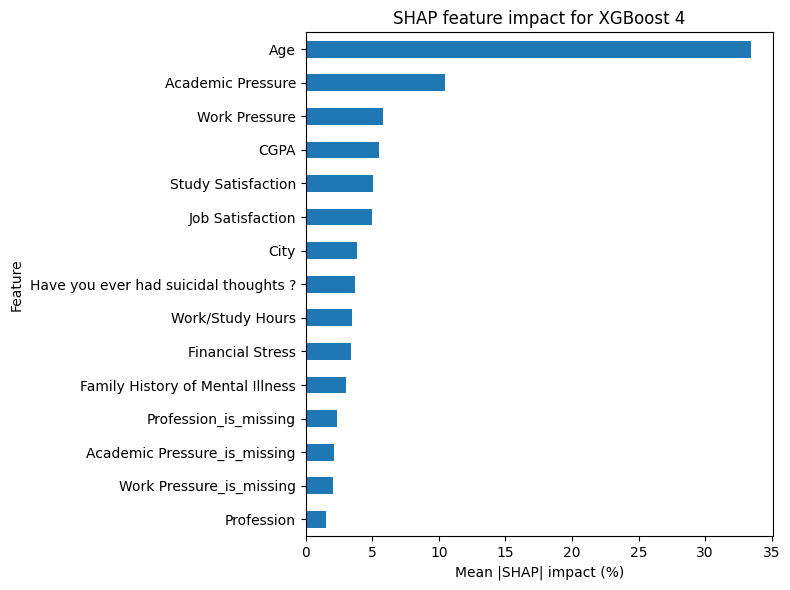

In [114]:
# SHAP: đo mức ảnh hưởng trung bình của từng feature tới prediction
import matplotlib.pyplot as plt
import shap

shap_sample_size = min(2000, len(X_val))
X_shap_raw = X_val.sample(n=shap_sample_size, random_state=RANDOM_STATE)

best_preprocessor = best_model.named_steps['preprocess']
best_classifier = best_model.named_steps['classifier']

X_shap_processed = best_preprocessor.transform(X_shap_raw)
feature_names = best_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(best_classifier)
shap_values = explainer.shap_values(X_shap_processed)

if isinstance(shap_values, list):
    shap_values_for_class = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_for_class = np.asarray(shap_values)
    if shap_values_for_class.ndim == 3:
        class_index = 1 if shap_values_for_class.shape[2] > 1 else 0
        shap_values_for_class = shap_values_for_class[:, :, class_index]

mean_abs_shap = np.abs(shap_values_for_class).mean(axis=0)
impact_percent = mean_abs_shap / mean_abs_shap.sum() * 100

shap_feature_importance = pd.DataFrame(
    {
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap,
        'mean_shap_value': shap_values_for_class.mean(axis=0),
        'impact_percent': impact_percent,
    }
).sort_values('impact_percent', ascending=False).reset_index(drop=True)

numeric_feature_names = list(best_preprocessor.transformers_[0][2])
categorical_feature_names = list(best_preprocessor.transformers_[1][2])
onehot_encoder = best_preprocessor.named_transformers_['cat'].named_steps['onehot']

original_feature_names = numeric_feature_names.copy()
for col, categories in zip(categorical_feature_names, onehot_encoder.categories_):
    original_feature_names.extend([col] * len(categories))

if len(original_feature_names) != len(feature_names):
    original_feature_names = feature_names

shap_original_feature_importance = (
    shap_feature_importance.assign(original_feature=original_feature_names)
    .groupby('original_feature', as_index=False)
    .agg(
        mean_abs_shap=('mean_abs_shap', 'sum'),
        mean_shap_value=('mean_shap_value', 'sum'),
        impact_percent=('impact_percent', 'sum'),
    )
    .sort_values('impact_percent', ascending=False)
    .reset_index(drop=True)
)

display(shap_original_feature_importance.head(20))
display(shap_feature_importance.head(20))

ax = shap_original_feature_importance.head(15).sort_values('impact_percent').plot.barh(
    x='original_feature',
    y='impact_percent',
    legend=False,
    figsize=(8, 6),
)
ax.set_xlabel('Mean |SHAP| impact (%)')
ax.set_ylabel('Feature')
ax.set_title(f'SHAP feature impact for {best_model_name}')
plt.tight_layout()
plt.show()

In [115]:
# Tạo submission bằng Stratified K-Fold ensemble 10 biến thể CatBoost/XGBoost tốt nhất
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
N_ENSEMBLE_MODELS = min(10, len(results_df))
PREDICTION_THRESHOLD = 0.5
ENSEMBLE_MODEL_NAMES = results_df['model'].head(N_ENSEMBLE_MODELS).tolist()

print('Ensemble models:')
for model_name in ENSEMBLE_MODEL_NAMES:
    print('-', model_name)

kfold = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_proba_by_model = {
    name: np.zeros(len(X_clean))
    for name in ENSEMBLE_MODEL_NAMES
}
test_proba_by_model = {
    name: np.zeros(len(X_test_clean))
    for name in ENSEMBLE_MODEL_NAMES
}
fold_results = []
final_models = {name: [] for name in ENSEMBLE_MODEL_NAMES}

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_clean, y), start=1):
    X_fold_train = X_clean.iloc[train_idx]
    X_fold_val = X_clean.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]

    for model_name in ENSEMBLE_MODEL_NAMES:
        model = Pipeline(
            steps=[
                ('preprocess', clone(preprocessor)),
                ('classifier', clone(tree_models[model_name])),
            ]
        )

        model.fit(X_fold_train, y_fold_train)

        val_proba = model.predict_proba(X_fold_val)[:, 1]
        val_pred = (val_proba >= PREDICTION_THRESHOLD).astype(int)

        oof_proba_by_model[model_name][val_idx] = val_proba
        test_proba_by_model[model_name] += model.predict_proba(X_test_clean)[:, 1] / N_SPLITS
        final_models[model_name].append(model)

        fold_results.append(
            {
                'model': model_name,
                'fold': fold,
                'accuracy': accuracy_score(y_fold_val, val_pred),
                'precision': precision_score(y_fold_val, val_pred),
                'recall': recall_score(y_fold_val, val_pred),
                'f1': f1_score(y_fold_val, val_pred),
                'roc_auc': roc_auc_score(y_fold_val, val_proba),
            }
        )

fold_results_df = pd.DataFrame(fold_results)
display(fold_results_df)
display(fold_results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
}))

oof_proba = np.mean(
    [oof_proba_by_model[model_name] for model_name in ENSEMBLE_MODEL_NAMES],
    axis=0,
)
test_proba = np.mean(
    [test_proba_by_model[model_name] for model_name in ENSEMBLE_MODEL_NAMES],
    axis=0,
)

submission = pd.DataFrame(
    {
        ID_COL: test_ids,
        TARGET_COL: (test_proba >= PREDICTION_THRESHOLD).astype(int),
    }
)
display(submission.head())

submission.to_csv('submission.csv', index=False)

print(f'Final submission model: top {N_ENSEMBLE_MODELS} CatBoost/XGBoost {N_SPLITS}-fold ensemble')
print('Prediction threshold:', PREDICTION_THRESHOLD)
print('OOF ROC-AUC:', roc_auc_score(y, oof_proba))
print('OOF accuracy:', accuracy_score(y, (oof_proba >= PREDICTION_THRESHOLD).astype(int)))
print('OOF F1:', f1_score(y, (oof_proba >= PREDICTION_THRESHOLD).astype(int)))

Ensemble models:
- XGBoost 4
- CatBoost 4
- CatBoost 1
- CatBoost 2
- CatBoost 5
- XGBoost 5
- CatBoost 3
- XGBoost 2
- XGBoost 1
- XGBoost 3


,model,fold,accuracy,precision,recall,f1,roc_auc
0,XGBoost 4,1,0.938948,0.841481,0.818111,0.829631,0.975289
1,CatBoost 4,1,0.938984,0.845262,0.813026,0.828831,0.975084
2,CatBoost 1,1,0.938451,0.843947,0.811265,0.827284,0.975020
3,CatBoost 2,1,0.938984,0.844282,0.814395,0.829069,0.975099
4,CatBoost 5,1,0.938486,0.844119,0.811265,0.827366,0.975043
5,XGBoost 5,1,0.938842,0.840426,0.818893,0.829520,0.975252
6,CatBoost 3,1,0.938806,0.844544,0.812830,0.828383,0.975078
7,XGBoost 2,1,0.938735,0.840056,0.818697,0.829239,0.975277
8,XGBoost 1,1,0.938380,0.840694,0.815373,0.827840,0.975222
9,XGBoost 3,1,0.938308,0.841180,0.814199,0.827470,0.974916


accuracy           precision              recall            \
                mean       std      mean       std      mean       std   
model                                                                    
CatBoost 1  0.939332  0.001261  0.848300  0.003636  0.811202  0.004593   
CatBoost 2  0.939488  0.001154  0.848239  0.003497  0.812336  0.004566   
CatBoost 3  0.939502  0.001194  0.848822  0.003841  0.811632  0.004016   
CatBoost 4  0.939431  0.001341  0.848358  0.004009  0.811789  0.004249   
CatBoost 5  0.939495  0.001236  0.849043  0.003726  0.811280  0.004386   
XGBoost 1   0.939460  0.001310  0.844574  0.003180  0.817225  0.004752   
XGBoost 2   0.939311  0.001317  0.843557  0.003319  0.817655  0.005553   
XGBoost 3   0.939190  0.001190  0.844589  0.003104  0.815387  0.004298   
XGBoost 4   0.939417  0.001504  0.843815  0.003744  0.818007  0.005571   
XGBoost 5   0.939403  0.001390  0.843837  0.004128  0.817890  0.004885   

                  f1             roc_auc            
                mean       std      mean       std  
model                                               
CatBoost 1  0.829332  0.003664  0.975186  0.001159  
CatBoost 2  0.829894  0.003375  0.975280  0.001163  
CatBoost 3  0.829807  0.003389  0.975203  0.001146  
CatBoost 4  0.829668  0.003810  0.975277  0.001136  
CatBoost 5  0.829728  0.003565  0.975255  0.001156  
XGBoost 1   0.830673  0.003840  0.975167  0.001098  
XGBoost 2   0.830399  0.003935  0.975215  0.001125  
XGBoost 3   0.829729  0.003468  0.974995  0.001192  
XGBoost 4   0.830707  0.004404  0.975202  0.001081  
XGBoost 5   0.830657  0.003970  0.975252  0.001075

,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0


Final submission model: top 10 CatBoost/XGBoost 5-fold ensemble
Prediction threshold: 0.5
OOF ROC-AUC: 0.9754192128708519
OOF accuracy: 0.9395309168443496
OOF F1: 0.8304436207102714
